<a href="https://colab.research.google.com/github/deepakri201/SR_for_NLST_Sybil/blob/main/demo/NLST_Sybil_FM_demo_part3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLST_Sybil_FM_demo_part3

In this notebook, we save out the features from MedSIGLip:
- medsiglip_features.csv file - the features extracted using the MedSIGLIP FM

Deepa Krishnaswamy

Brigham and Women's Hospital

July 2025

To do:
- insert instructions for HF_TOKEN

Notes:
- Colab Pro - L4 - taking about 20 minutes.

# Parameterization

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
# Copy the nlst_sybil_fm.csv from Google Drive to here
!cp "/content/gdrive/MyDrive/Colab Notebooks/SR_NLST_Sybil/demo/nlst_sybil_fm.csv" "/content/"

In [3]:
#@title Enter your Project ID here
# initialize this variable with your Google Cloud Project ID!
project_name = "idc-external-018" #@param {type:"string"}

import os
os.environ["GCP_PROJECT_ID"] = project_name

!gcloud config set project $project_name

from google.colab import auth
auth.authenticate_user()

Updated property [core/project].


# Environment setup for MedSIGLip

In [4]:
# @title ## Authenticate with HuggingFace, skip if you have a HF_TOKEN secret

# Authenticate user for HuggingFace if needed. Enter token below if requested.
from huggingface_hub.utils import HfFolder

if HfFolder.get_token() is None:
    from huggingface_hub import notebook_login
    notebook_login()

In [5]:
import os
import sys
import pandas as pd
import numpy as np

In [6]:
!pip install idc-index

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 12.6 MB/s eta 0:00:00
  Attempting uninstall: duckdb
    Found existing installation: duckdb 1.3.2
    Uninstalling duckdb-1.3.2:
      Successfully uninstalled duckdb-1.3.2


In [7]:
from idc_index import IDCClient

idc_client = IDCClient.client()

In [8]:
from google.cloud import bigquery
from google.cloud import storage

In [9]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 87.7 MB/s eta 0:00:00


In [10]:
import pydicom
from PIL import Image
from tensorflow.image import resize as tf_resize
import tensorflow as tf
from transformers import AutoProcessor, SiglipVisionModel, AutoModel
import torch
import matplotlib.pyplot as plt

# Download DICOM data

In [11]:
!cp "/content/gdrive/MyDrive/Colab Notebooks/SR_NLST_Sybil/demo/nlst_sybil_fm.csv" "/content/"

In [12]:
df_sr_and_nlst = pd.read_csv("/content/nlst_sybil_fm.csv")

In [13]:
# Specify classes to use for the classification
# Keep two stages for classification
print(len(list(set(df_sr_and_nlst[df_sr_and_nlst['de_stag_mapped']==0]['PatientID'].values))))
print(len(list(set(df_sr_and_nlst[df_sr_and_nlst['de_stag_mapped']==1]['PatientID'].values))))

df_sr_and_nlst_subset = df_sr_and_nlst[df_sr_and_nlst['de_stag_mapped'].isin([0,1])]

263
61


In [14]:
SeriesInstanceUIDs_temp = sorted(list(set(df_sr_and_nlst_subset['SeriesInstanceUID'].values)))
df_sr_and_nlst_subset = df_sr_and_nlst_subset[df_sr_and_nlst_subset['SeriesInstanceUID'].isin(SeriesInstanceUIDs_temp)]

# We need to remove the places where the SOPInstanceUID appears twice - means >1 lesion on a slice - just to keep it simple for now.
df_sr_and_nlst_subset = df_sr_and_nlst_subset[df_sr_and_nlst_subset['SOPInstanceUID'].duplicated(keep=False) == False]
print('num_sop: ' + str(len(df_sr_and_nlst_subset)))

num_series = len(SeriesInstanceUIDs_temp)
print('num_series: ' + str(num_series))

# It's fine that the num_sop>num_series. Some series have multiple SOPInstanceUIDs, so there are lesions on multiple slices.

num_sop: 525
num_series: 465


In [15]:
# Since we just need the slice the lesion is on - use gsutil for now to copy specific instances.

dicom_directory = "/content/dicom"
if not os.path.isdir(dicom_directory):
  os.mkdir(dicom_directory)

# First use bigquery to get the gcs_url
SOPInstanceUID_list = list(df_sr_and_nlst_subset['SOPInstanceUID'].values)
client_bq = bigquery.Client(project=project_name)

query = f"""
    SELECT
      SOPInstanceUID,
      gcs_url
    FROM
      `bigquery-public-data.idc_current.dicom_all`
    WHERE
      SOPInstanceUID IN UNNEST(@SOPInstanceUID_list)
      """

job_config = bigquery.QueryJobConfig(query_parameters=[bigquery.ArrayQueryParameter("SOPInstanceUID_list", "STRING", SOPInstanceUID_list)])
df_idc = client_bq.query(query, job_config=job_config).to_dataframe()

In [16]:
print(len(SOPInstanceUID_list))
print(len(df_idc))

525
525


In [17]:
# Copy files

gcs_url_list = df_idc['gcs_url'].values

# Write out gcs_urls to text file
gcs_url_list_filename = "/content/gcs_urls.txt"
with open(gcs_url_list_filename, 'w') as f:
  for gcs_url in gcs_url_list:
    f.write(gcs_url + '\n')

# Then copy
!gsutil -m cp -I < $gcs_url_list_filename $dicom_directory

# # Then download using gsutil
# num_files = len(gcs_url_list)
# checkpoints = {int((num_files) * i / 10) for i in range(1, 11)}
# dicom_filenames = []
# index = 0
# for gcs_url, SOPInstanceUID in zip(gcs_url_list, SOPInstanceUID_list):
#   input_filename = gcs_url
#   output_filename = os.path.join(dicom_directory, SOPInstanceUID + ".dcm")
#   !gsutil -m cp -r $input_filename $output_filename
#   dicom_filenames.append(output_filename)
#   if index in checkpoints:
#     print(f"{(index / num_files) * 100:.0f}% of DICOM files processed.")
#   index += 1


Copying gs://idc-open-data/326b5dbc-07dd-426f-8426-7f001c66228c/e8720a9a-009a-4fa8-8a9b-f859d8bd7c7a.dcm...
Copying gs://idc-open-data/fbaceb3d-8d57-4be0-bfda-b1e4260dc36b/fad25eb2-b461-4778-82b0-1a6be7e5f732.dcm...
Copying gs://idc-open-data/724eb4c8-9c29-470c-b945-4e750a7a9613/645eb91c-69c2-46c9-bc3d-4a7ca4537610.dcm...
Copying gs://idc-open-data/d1a25925-c5f6-42c9-acac-39754ee8f9c8/234d4b47-baad-4e13-b0ca-73be8daeb61f.dcm...
Copying gs://idc-open-data/c37f47a5-abdf-4c1a-819f-7d1d9be6d362/259dfa12-0e8a-4fe6-9469-da6900e26325.dcm...
Copying gs://idc-open-data/e11d0e5b-c7ed-47ed-8f37-ee8013a55823/2656bccb-42a8-42dc-9bf7-af0714ce0a39.dcm...
Copying gs://idc-open-data/7cebb742-08e5-43a3-b3d5-34c9886e7aaf/0cdf36fb-f2cb-4a26-8aad-b2ff22e2149c.dcm...
Copying gs://idc-open-data/97786dd6-4f4e-43ef-970d-6d4aa637a836/a677f521-406a-40d9-92a6-02487a5594e9.dcm...
Copying gs://idc-open-data/cfe6d108-2787-492f-a9f2-e5bd225ebdd0/b8ad0f50-239b-4c39-9b4c-9c5eb88bac31.dcm...
Copying gs://idc-open-data/e

In [ ]:
# Rename the files with the SOPInstanceUID instead

dicom_files = [os.path.join(dicom_directory,os.path.basename(f)) for f in gcs_url_list]
print(dicom_files)
print(len(dicom_files))

dicom_files_renamed = [os.path.join(dicom_directory,f+'.dcm') for f in SOPInstanceUID_list]
[os.rename(f,g) for f,g in zip(dicom_files, dicom_files_renamed)]

# Process images

In [20]:
# First form a df_for_csv holding the information about the tumor location

df_for_csv = pd.DataFrame()
SOPInstanceUID_for_csv = list(df_sr_and_nlst_subset['SOPInstanceUID'].values)
df_for_csv['PatientID'] = df_sr_and_nlst_subset['PatientID'].values
df_for_csv['SeriesInstanceUID'] = df_sr_and_nlst_subset['SeriesInstanceUID'].values
df_for_csv['SOPInstanceUID'] = df_sr_and_nlst_subset['SOPInstanceUID'].values
df_for_csv['image_path'] = [os.path.join("/content/dicom",f+'.dcm') for f in df_for_csv['SOPInstanceUID'].values]

center_x_voxel_list = []
center_y_voxel_list = []
height_voxel_list = []
width_voxel_list = []
min_x_voxel_list = []
max_x_voxel_list = []
min_y_voxel_list = []
max_y_voxel_list = []

dicom_files = df_for_csv['image_path'].values

# Map back to the pixel/voxel coordinates
for index, dicom_file in enumerate(dicom_files):

  center_x = df_sr_and_nlst_subset['center_x'].values[index]
  center_y = df_sr_and_nlst_subset['center_y'].values[index]
  ipp0 = df_sr_and_nlst_subset['ipp0'].values[index]
  ipp1 = df_sr_and_nlst_subset['ipp1'].values[index]
  width = df_sr_and_nlst_subset['width'].values[index]
  height = df_sr_and_nlst_subset['height'].values[index]
  pixel_spacing_x = df_sr_and_nlst_subset['pixel_spacing_x'].values[index]
  pixel_spacing_y = df_sr_and_nlst_subset['pixel_spacing_y'].values[index]

  center_x_voxel = - ((ipp0 - center_x) / pixel_spacing_x)
  center_y_voxel = - ((ipp1 - center_y) / pixel_spacing_y)

  height_voxel = height / pixel_spacing_y
  width_voxel = width / pixel_spacing_x

  min_x_voxel = np.int32(np.round(center_x_voxel-(width_voxel/2)))
  max_x_voxel = np.int32(np.round(center_x_voxel+(width_voxel/2)))
  min_y_voxel = np.int32(np.round(center_y_voxel-(height_voxel/2)))
  max_y_voxel = np.int32(np.round(center_y_voxel+(height_voxel/2)))

  center_x_voxel_list.append(center_x_voxel)
  center_y_voxel_list.append(center_y_voxel)
  height_voxel_list.append(height_voxel)
  width_voxel_list.append(width_voxel)
  min_x_voxel_list.append(min_x_voxel)
  max_x_voxel_list.append(max_x_voxel)
  min_y_voxel_list.append(min_y_voxel)
  max_y_voxel_list.append(max_y_voxel)

df_for_csv['center_x_voxel'] = center_x_voxel_list
df_for_csv['center_y_voxel'] = center_y_voxel_list
df_for_csv['height_voxel'] = height_voxel_list
df_for_csv['width_voxel'] = width_voxel_list
df_for_csv['min_x_voxel'] = min_x_voxel_list
df_for_csv['max_x_voxel'] = max_x_voxel_list
df_for_csv['min_y_voxel'] = min_y_voxel_list
df_for_csv['max_y_voxel'] = max_y_voxel_list


In [21]:
df_for_csv.head()

,PatientID,SeriesInstanceUID,SOPInstanceUID,image_path,center_x_voxel,center_y_voxel,height_voxel,width_voxel,min_x_voxel,max_x_voxel,min_y_voxel,max_y_voxel
0,122866,1.2.840.113654.2.55.80557134350152339289139946...,1.2.840.113654.2.55.85140172863189651811817196...,/content/dicom/1.2.840.113654.2.55.85140172863...,119.500004,311.500004,41.000000,47.000000,96,143,291,332
1,108061,1.2.840.113654.2.55.10807774762936711010605398...,1.2.840.113654.2.55.98174634521976004347766089...,/content/dicom/1.2.840.113654.2.55.98174634521...,193.500001,144.999994,60.000000,67.000000,160,227,115,175
2,108061,1.2.840.113654.2.55.17922076604756733648279336...,1.2.840.113654.2.55.16614716909394342742616011...,/content/dicom/1.2.840.113654.2.55.16614716909...,179.499991,177.499990,60.999997,67.000000,146,213,147,208
3,207830,1.3.6.1.4.1.14519.5.2.1.7009.9004.309348115505...,1.3.6.1.4.1.14519.5.2.1.7009.9004.273265747347...,/content/dicom/1.3.6.1.4.1.14519.5.2.1.7009.90...,165.499995,180.500002,62.999995,66.999995,132,199,149,212
4,207830,1.3.6.1.4.1.14519.5.2.1.7009.9004.263827526097...,1.3.6.1.4.1.14519.5.2.1.7009.9004.301103650372...,/content/dicom/1.3.6.1.4.1.14519.5.2.1.7009.90...,139.000002,170.000000,77.999997,68.000001,105,173,131,209


In [22]:
# Resize function

INPUT_DIMENSION = [448, 448]

def resize(image_pil):
  # Convert from PIL image to numpy
  image_np = np.array(image_pil).astype(np.float32)
  # Rescale
  image_np = (image_np-np.min(image_np)) / (np.max(image_np)-np.min(image_np))
  # Add channel dimension
  image_np = np.expand_dims(image_np, axis=-1)
  # Resize
  image_resized = tf_resize(image_np, size=INPUT_DIMENSION, method='bilinear', antialias=False)
  # Remove channel dimension
  image_resized = tf.squeeze(image_resized, axis=-1)
  # Scale
  image_resized = (image_resized.numpy() * 255).clip(0, 255).astype(np.uint8)
  # Need to have 3 channels
  image_rgb = np.stack([image_resized] * 3, axis=-1)

  return Image.fromarray(image_rgb)


# Now read in and crop the DICOM files
cropped_imgs = []
cropped_imgs_pil = []

for index, dicom_file in enumerate(dicom_files):
    dcm = pydicom.dcmread(dicom_file)
    img = dcm.pixel_array

    # crop using y for rows and x for columns (image[y1:y2, x1:x2])
    min_y_voxel = df_for_csv['min_y_voxel'].values[index]
    max_y_voxel = df_for_csv['max_y_voxel'].values[index]
    min_x_voxel = df_for_csv['min_x_voxel'].values[index]
    max_x_voxel = df_for_csv['max_x_voxel'].values[index]
    cropped_img = img[min_y_voxel:max_y_voxel, min_x_voxel:max_x_voxel]

    cropped_imgs.append(cropped_img)
    cropped_imgs_pil.append(Image.fromarray(cropped_img))

# Resize to 448x448 using TensorFlow
imgs = [resize(img) for img in cropped_imgs_pil]


# Verify images and crop by plotting

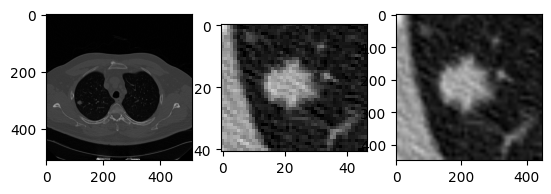

In [23]:
# Try plotting for one
index = 0

# Get original image
im = np.array(pydicom.dcmread(dicom_files[index]).pixel_array)

# Get cropped image
min_x = df_for_csv['min_x_voxel'].values[index]
max_x = df_for_csv['max_x_voxel'].values[index]
min_y = df_for_csv['min_y_voxel'].values[index]
max_y = df_for_csv['max_y_voxel'].values[index]
im_crop = im[min_y:max_y, min_x:max_x]

# Get cropped image that is now resized
im_crop_and_resize = np.array(imgs[index])

plt.subplot(1,3,1)
plt.imshow(im, cmap='gray')
plt.subplot(1,3,2)
plt.imshow(im_crop, cmap='gray')
plt.subplot(1,3,3)
plt.imshow(im_crop_and_resize, cmap='gray')
plt.show()

# Obtain Image Embeddings

In [24]:
# @title Prepare model and inputs

model = SiglipVisionModel.from_pretrained("google/medsiglip-448")
processor = AutoProcessor.from_pretrained("google/medsiglip-448")

inputs = processor(images=imgs, padding="max_length", return_tensors="pt")

config.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.51G [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/360 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/809 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/455 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.40M [00:00<?, ?B/s]

In [25]:
# @title Run model

import time
start_time = time.time()

with torch.no_grad():
    outputs = model(**inputs)

end_time = time.time()
print('Elapsed time to run model: ' + str((end_time-start_time)/60))

Elapsed time to run model: 19.74202026526133


In [26]:
# @title Normalize outputs to embeddings

# This matches the embeddings produced by the SiglipModel class.
output_embeddings = outputs["pooler_output"] / outputs["pooler_output"].norm(p=2, dim=-1, keepdim=True)

In [27]:
output_embeddings_np = output_embeddings.numpy()
print(output_embeddings_np.shape)

(525, 1152)


## Save image embeddings

In [28]:
# save the df_for_csv file

# Save the dataframe so can load and train/val/test later.
df_for_csv.to_csv("/content/medsiglip_info.csv")

In [29]:
# Temporarily save to drive

!cp "/content/medsiglip_info.csv" "/content/gdrive/MyDrive/Colab Notebooks/SR_NLST_Sybil/demo/"

In [30]:
df_for_csv.columns

Index(['PatientID', 'SeriesInstanceUID', 'SOPInstanceUID', 'image_path',
       'center_x_voxel', 'center_y_voxel', 'height_voxel', 'width_voxel',
       'min_x_voxel', 'max_x_voxel', 'min_y_voxel', 'max_y_voxel'],
      dtype='object')

In [31]:
df_sr_and_nlst_subset.columns

Index(['Unnamed: 0', 'PatientID', 'SeriesInstanceUID', 'TrackingIdentifier',
       'TrackingUID', 'SOPInstanceUID', 'FindingType', 'FindingSite', 'width',
       'height', 'center_x', 'center_y', 'sr_filename', 'StudyInstanceUID',
       'pixel_spacing_x', 'pixel_spacing_y', 'ipp0', 'ipp1', 'ipp2',
       'StudyDate', 'sct_slice_num', 'study_yr', 'Rows', 'Columns',
       'sop_count_per_series', 'de_stag_mapped'],
      dtype='object')

In [32]:
sop_list = df_for_csv['SOPInstanceUID'].values
labels = df_sr_and_nlst_subset[df_sr_and_nlst_subset['SOPInstanceUID'].isin(sop_list)]['de_stag_mapped'].values
print(len(sop_list))
print(len(labels))

525
525


In [34]:
# Create a file similar to the FMCIB one
# PatientID, SeriesInstanceUID, SOPInstanceUID,
# 'center_x_voxel'
# 'center_y_voxel'
# 'height_voxel'
# 'width_voxel'
# 'min_x_voxel'
# 'max_x_voxel'
# 'min_y_voxel'
# 'max_y_voxel'
# then columns for 0 to 1151

df_for_csv2 = df_for_csv.copy(deep=True)

# Add classification label - stage 0/1
df_for_csv2['label'] = labels
# Create column names
col_names = [f"pred_{i}" for i in range(1152)]
# Create a new DataFrame from the output embeddings numpy array
preds_df = pd.DataFrame(output_embeddings_np, columns=col_names)
# Concatenate along columns
df_for_csv2 = pd.concat([df_for_csv2, preds_df], axis=1)

# Save csv
df_for_csv2.to_csv("/content/medsiglip_features.csv")

In [35]:
# Temporarily save to drive

!cp "/content/medsiglip_features.csv" "/content/gdrive/MyDrive/Colab Notebooks/SR_NLST_Sybil/demo/"

In [36]:
print(df_for_csv2.shape)

(525, 1165)


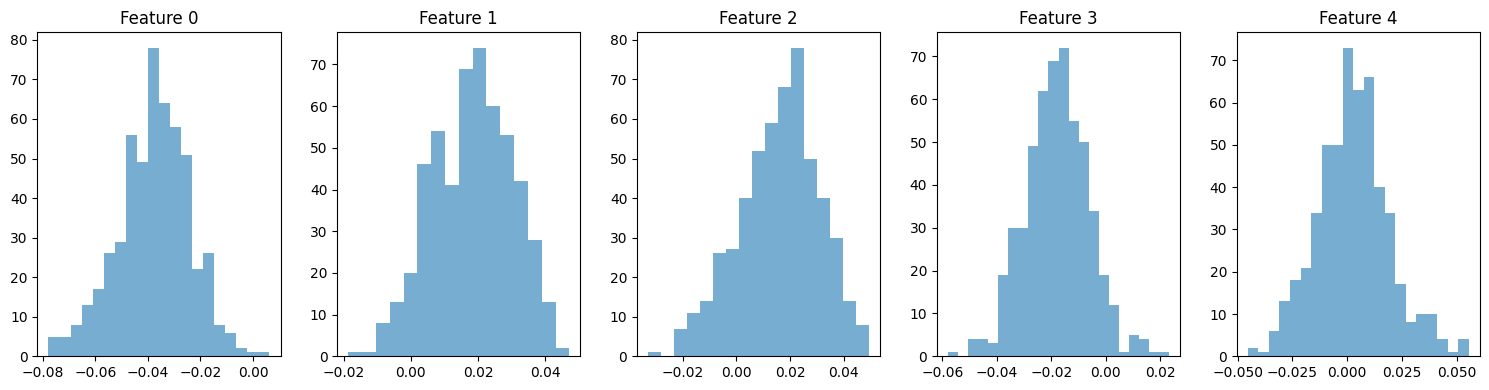

In [37]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 5, figsize=(15, 4), tight_layout=True)

for i, ax in enumerate(axs):
    ax.hist(df_for_csv2[f"pred_{i}"], bins='auto', alpha=0.6)
    ax.set_title(f'Feature {i}')

plt.show()